### Exercise on page 220 of the CEC616 notes

In [1]:
import tensorflow as tf
from tensorflow import keras 
import matplotlib.pyplot as plt 
%matplotlib inline
import numpy as np 

In [2]:
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()
print(len(X_train))
print(len(X_test))
print(X_train[0].shape)
print(X_train[0])

60000
10000
(28, 28)
[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3  18  18  18 126 136
  175  26 166 255 247 127   0   0   0   0]
 [  0   0   0   0   0   0   0   0  30  36  94 154 170 253 253 253 253 253
  225 172 253 242 195  64   0   0   0   0]
 [  0   0   0   0   0   0   0  49 238 253 253 253 253 253 253 253 253 251
   93  82  82  56  39   0   0   0   0   0]
 [  0   0   0   0   0   0   0  18 219 253 2

5


[[0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.    

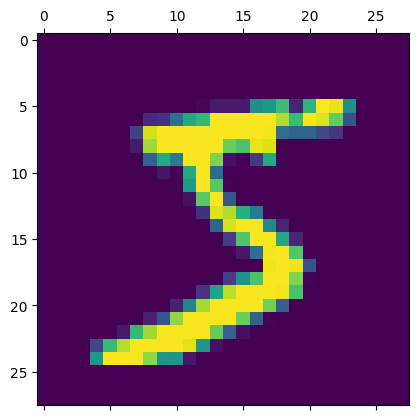

In [3]:
plt.matshow(X_train[0])
print(y_train[0])
X_train = X_train / 255
X_test = X_test / 255
print(X_train[0])
X_train_flattened = X_train.reshape(len(X_train), 28*28)
X_test_flattened = X_test.reshape(len(X_test), 28*28)
print(X_train_flattened.shape)
print(X_train_flattened[0])

c:\Users\xinod\Documents\Projects\CEC616\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 6ms/step - accuracy: 0.8784 - loss: 0.4666
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 25s 13ms/step - accuracy: 0.9148 - loss: 0.3039
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 38s 11ms/step - accuracy: 0.9207 - loss: 0.2837
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 44s 13ms/step - accuracy: 0.9235 - loss: 0.2730
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 38s 11ms/step - accuracy: 0.9259 - loss: 0.2668
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9246 - loss: 0.2694
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step
[2.3229931e-02 4.1085281e-07 6.6037700e-02 9.6198851e-01 3.3700299e-03
 1.1330885e-01 1.3617954e-06 9.9980378e-01 6.0600121e-02 5.7687569e-01]


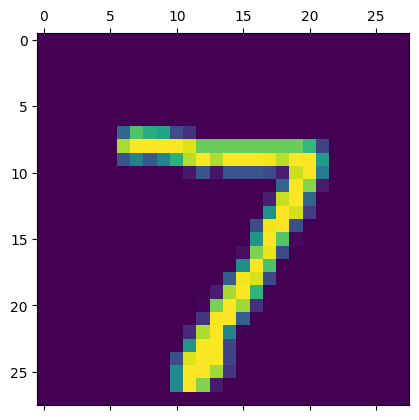

In [4]:
model = keras.Sequential([
    keras.layers.Dense(10, input_shape=(784,), activation='sigmoid')
])
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model.fit(X_train_flattened, y_train, epochs=5)
model.evaluate(X_test_flattened, y_test)
y_predicted = model.predict(X_test_flattened)
print(y_predicted[0])
plt.matshow(X_test[0])

In [5]:
np.argmax(y_predicted[0])
y_predicted_labels = [np.argmax(i) for i in y_predicted]
print(y_predicted_labels[:5])
cm = tf.math.confusion_matrix(labels=y_test, predictions=y_predicted_labels)
print(cm)

[np.int64(7), np.int64(2), np.int64(1), np.int64(0), np.int64(4)]
tf.Tensor(
[[ 960    0    1    2    0    5    7    3    2    0]
 [   0 1117    3    2    0    1    4    2    6    0]
 [   4    9  929   17    8    3   12   11   37    2]
 [   1    0   19  936    1   16    3   10   17    7]
 [   1    2    4    1  925    0   10    4    9   26]
 [   7    2    3   41   10  773   13    5   32    6]
 [   8    3    6    1    7   14  915    2    2    0]
 [   1    5   23    9   10    0    0  955    3   22]
 [   5   12    6   32    9   28    8   14  856    4]
 [  10    7    1   12   52    9    0   31    7  880]], shape=(10, 10), dtype=int32)


Text(95.72222222222221, 0.5, 'Truth')

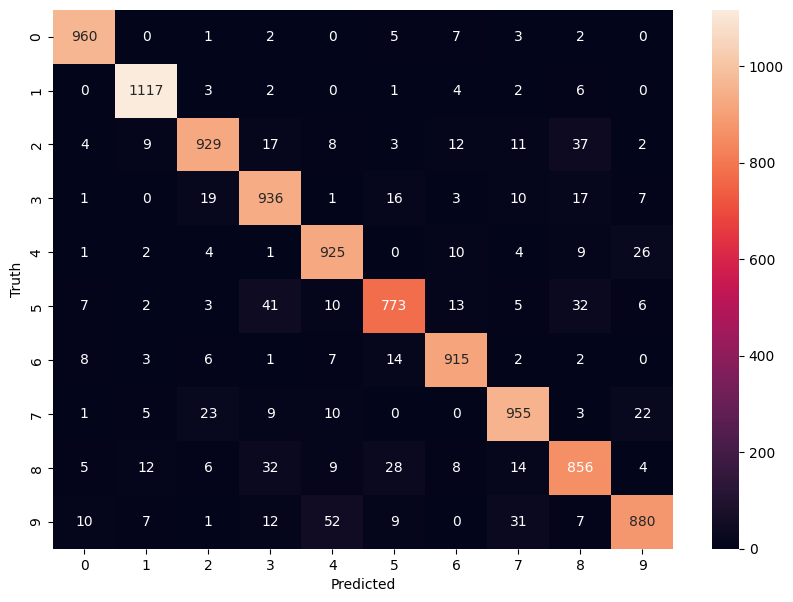

In [6]:
import seaborn as sn
plt.figure(figsize=(10,7))
sn.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Truth')

In [7]:
model = keras.Sequential([
    keras.layers.Dense(100, input_shape=(784,), activation='relu'),
    keras.layers.Dense(10, activation='sigmoid')
])
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model.fit(X_train_flattened, y_train, epochs=5)

c:\Users\xinod\Documents\Projects\CEC616\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - accuracy: 0.9225 - loss: 0.2729
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 26s 10ms/step - accuracy: 0.9635 - loss: 0.1250
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - accuracy: 0.9737 - loss: 0.0878
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.9797 - loss: 0.0672
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 24s 10ms/step - accuracy: 0.9835 - loss: 0.0530


313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9755 - loss: 0.0800


Text(95.72222222222221, 0.5, 'Truth')

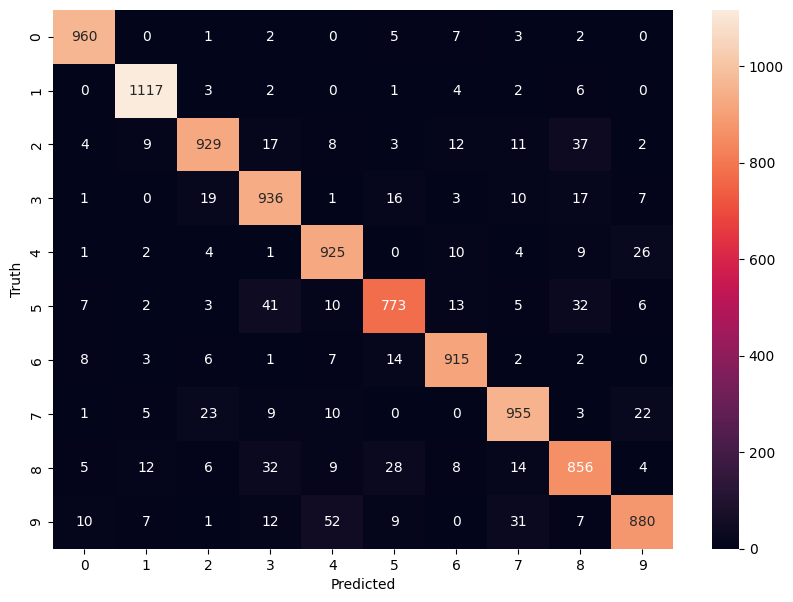

In [8]:
model.evaluate(X_test_flattened, y_test)
y_predicted_labels = [np.argmax(i) for i in y_predicted]
cm = tf.math.confusion_matrix(labels=y_test, predictions=y_predicted_labels)

plt.figure(figsize=(10,7))
sn.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Truth')

In [9]:
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28,28)),
    keras.layers.Dense(100, activation='relu'),
    keras.layers.Dense(10, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',\
    metrics=['accuracy']
)

model.fit(X_train, y_train, epochs=10)
model.evaluate(X_test, y_test)

c:\Users\xinod\Documents\Projects\CEC616\.venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step - accuracy: 0.9221 - loss: 0.2733
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 22s 7ms/step - accuracy: 0.9630 - loss: 0.1257
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 25s 10ms/step - accuracy: 0.9741 - loss: 0.0877
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.9797 - loss: 0.0666
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - accuracy: 0.9845 - loss: 0.0532
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 6ms/step - accuracy: 0.9865 - loss: 0.0425
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 6ms/step - accuracy: 0.9894 - loss: 0.0345
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 24s 7ms/step - accuracy: 0.9914 - loss: 0.0280
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 32s 14ms/step - accuracy: 0.9923 - loss: 0.0240
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 30s 8ms/step - accuracy: 0.9942 - loss: 0.0194
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9759 - loss: 0.0864


[0.08641928434371948, 0.9758999943733215]